In [1]:
%pip install opencv-python numpy pandas scikit-learn matplotlib seaborn joblib

  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   -----------------

  You can safely remove it manually.
  You can safely remove it manually.


In [2]:
import os
import cv2
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [31]:
# =========================
# 0) CONFIG
# =========================
BASE_DIR = "C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1"   # change if needed
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

FREQS = [500, 1000, 2000, 3000, 4000, 6000, 8000]   # fixed order
NUM_POINTS = len(FREQS)

# dB axis mapping (typical in your charts)
DB_MIN = -10
DB_MAX = 110

# Output artifacts
OUT_DIR = "ml_threshold_model"
os.makedirs(OUT_DIR, exist_ok=True)
MODEL_PATH_RF = os.path.join(OUT_DIR, "rf_model.joblib")
MODEL_PATH_SVM = os.path.join(OUT_DIR, "svm_model.joblib")
LABEL_ENCODER_PATH = os.path.join(OUT_DIR, "label_encoder.joblib")
META_PATH = os.path.join(OUT_DIR, "meta.json")

In [ ]:

# 1) PLOT AREA DETECTION

def detect_plot_area(img_bgr):
    """
    Detect the main plot/grid rectangle region.
    Strategy:
    - Canny edges + dilation
    - Find external contours
    - Pick largest rectangle-like contour
    Returns (x, y, w, h)
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    kernel = np.ones((5, 5), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best = None
    best_area = 0

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        # Heuristics: ignore tiny rectangles
        if area > best_area and w > 200 and h > 200:
            best_area = area
            best = (x, y, w, h)

    if best is None:
        raise ValueError("Plot area not detected (try adjusting heuristics).")

    return best


In [ ]:

# 2) DETECT BLUE 'X' MARKERS

def detect_blue_x_centroids(plot_bgr):
    """
    Returns list of (cx, cy) centroids for detected blue x-marker components.
    Works best if x markers are a strong blue.
    """
    hsv = cv2.cvtColor(plot_bgr, cv2.COLOR_BGR2HSV)

    # Blue range (adjust if needed)
    lower_blue = np.array([90, 60, 50])
    upper_blue = np.array([140, 255, 255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Morph cleanup
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel) 
    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    points = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        cx, cy = centroids[i]

        # Filter component size (tweakable)
        if 20 < area < 3000:
            points.append((float(cx), float(cy)))

    return points

In [ ]:

# 3) EXTRACT THRESHOLDS (7 points)

def extract_thresholds_from_image(img_path, debug=False):
    """
    Steps:
    1) Read image
    2) Detect plot area
    3) Detect blue x markers inside plot
    4) Sort left->right, take 7 points
    5) Convert y pixel -> dB with linear mapping
    Returns: np.array of length 7 thresholds in dB
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    px, py, pw, ph = detect_plot_area(img)
    plot = img[py:py+ph, px:px+pw]
    pts = detect_blue_x_centroids(plot)

    if len(pts) < NUM_POINTS:
        raise ValueError(f"Not enough blue markers found in {img_path} (found {len(pts)}).")

    # Sort left->right
    pts.sort(key=lambda p: p[0])

    # Sometimes extra blue pixels exist; keep the leftmost 7 centroids
    pts = pts[:NUM_POINTS]

    thresholds = []
    for (cx, cy) in pts:
        # cy=0 at top -> DB_MIN ; cy=ph at bottom -> DB_MAX
        db = DB_MIN + (cy / float(ph)) * (DB_MAX - DB_MIN)
        thresholds.append(db)
        thresholds = np.array(thresholds, dtype=np.float32)

    if debug:
        dbg = plot.copy()
        for (cx, cy) in pts:
            cv2.circle(dbg, (int(cx), int(cy)), 6, (0, 0, 255), -1)
        plt.figure(figsize=(7, 4))
        plt.title("Detected marker centroids (red dots)")
        plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

        print("Thresholds:", thresholds)

    return thresholds

In [ ]:

# 4) ENGINEER FEATURES

def thresholds_to_features(thr):
    """
    thr is length-7 array in order of FREQS.
    We create clinically meaningful features + raw thresholds.
    """
    thr = np.array(thr, dtype=np.float32)

    lf = thr[:2]      # 500-1k
    speech = thr[:5]  # 500-4k
    hf = thr[4:]      # 4k-8k

    feats = {
        "avg_threshold": float(thr.mean()),
        "speech_avg": float(speech.mean()),
        "lf_avg": float(lf.mean()),
        "hf_avg": float(hf.mean()),
        "slope_hf_minus_lf": float(hf.mean() - lf.mean()),
        "max_threshold": float(thr.max()),
        "min_threshold": float(thr.min()),
        "variance": float(thr.var()),
        "range": float(thr.max() - thr.min()),
    }

    # add each frequency threshold as a separate feature
    for i, f in enumerate(FREQS):
        feats[f"thr_{f}"] = float(thr[i])

    return feats

In [50]:
def build_feature_dataframe(root_dir):
    """
    root_dir: train or test folder with subfolders as labels.
    Returns dataframe with features + label + image_path
    """
    rows = []
    skipped = 0
    processed = 0

    labels = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    for label in labels:
        folder = os.path.join(root_dir, label)

        for fn in os.listdir(folder):
            path = os.path.join(folder, fn)

            # Skip non-files (folders, shortcuts, etc.)
            if not os.path.isfile(path):
                continue

            # Allow common image extensions
            if not fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff", ".jfif")):
                continue

            try:
                thr = extract_thresholds_from_image(path, debug=False)
                feats = thresholds_to_features(thr)
                feats["label"] = label
                feats["image_path"] = path
                rows.append(feats)
                processed += 1

            except Exception as e:
                skipped += 1
                print(f"[WARN] Skipping {path} -> {e}")

    df = pd.DataFrame(rows)
    print(f"[INFO] Finished {root_dir}: processed={processed}, skipped={skipped}, kept={len(df)}")
    return df


In [ ]:
# =========================
# 6) TRAIN + EVALUATE
# =========================
def train_and_evaluate():
    print("Building train features...")
    df_train = build_feature_dataframe(TRAIN_DIR)
    print("Building test features...") 
    df_test = build_feature_dataframe(TEST_DIR)

    print("\nTrain samples:", len(df_train), "| Test samples:", len(df_test))
    if len(df_train) == 0 or len(df_test) == 0:
        raise RuntimeError("No samples found. Check folder paths and image formats.")

    # Prepare X/y
    feature_cols = [c for c in df_train.columns if c not in ("label", "image_path")]

    X_train = df_train[feature_cols].values
    y_train = df_train["label"].values

    X_test = df_test[feature_cols].values
    y_test = df_test["label"].values

    # Encode labels
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    # Save label encoder
    joblib.dump(le, LABEL_ENCODER_PATH)

    # ---------- MODEL 1: Random Forest ----------
    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        random_state=42,
        class_weight="balanced"
    )
    rf.fit(X_train, y_train_enc)
    pred_rf = rf.predict(X_test)

    acc_rf = accuracy_score(y_test_enc, pred_rf)
    print("\n=== Random Forest نتائج ===")
    print("Accuracy:", round(acc_rf * 100, 2), "%")
    print(classification_report(y_test_enc, pred_rf, target_names=le.classes_))

    cm_rf = confusion_matrix(y_test_enc, pred_rf)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_rf, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_, cmap="Blues")
    plt.title("Confusion Matrix - Random Forest")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    joblib.dump({"model": rf, "feature_cols": feature_cols}, MODEL_PATH_RF)

    # ---------- MODEL : SVM (with scaling) ----------
    svm = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ])
    svm.fit(X_train, y_train_enc)
    pred_svm = svm.predict(X_test)

    acc_svm = accuracy_score(y_test_enc, pred_svm)
    print("\n=== SVM (RBF)  ===")
    print("Accuracy:", round(acc_svm * 100, 2), "%")
    print(classification_report(y_test_enc, pred_svm, target_names=le.classes_))

    cm_svm = confusion_matrix(y_test_enc, pred_svm)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_svm, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_, cmap="Blues")
    plt.title("Confusion Matrix - SVM")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    joblib.dump({"model": svm, "feature_cols": feature_cols}, MODEL_PATH_SVM)

    # Save metadata
    meta = {
        "freqs": FREQS,
        "db_min": DB_MIN,
        "db_max": DB_MAX,
        "train_dir": TRAIN_DIR,
        "test_dir": TEST_DIR,
        "num_train_samples": int(len(df_train)),
        "num_test_samples": int(len(df_test)),
        "labels": le.classes_.tolist(),
        "feature_cols": feature_cols,
        "rf_accuracy": float(acc_rf),
        "svm_accuracy": float(acc_svm),
    }
    with open(META_PATH, "w") as f:
        json.dump(meta, f, indent=2)

    print("\n✅ Saved artifacts in:", OUT_DIR)
    print(" -", MODEL_PATH_RF)
    print(" -", MODEL_PATH_SVM)
    print(" -", LABEL_ENCODER_PATH)
    print(" -", META_PATH)

    return meta

In [ ]:
from sklearn.cluster import KMeans

def merge_close_points(pts, dist_px=12):
    """
    Merge points that are very close (X markers often split into 2-3 blobs).
    pts: list of (cx, cy, area)
    returns merged list of (cx, cy, area)
    """
    if not pts:
        return []

    pts = sorted(pts, key=lambda p: p[0])  # sort by x 
    merged = []
    used = [False]*len(pts)

    for i in range(len(pts)):
        if used[i]:
            continue
        cx, cy, area = pts[i]
        group = [(cx, cy, area)]
        used[i] = True

        for j in range(i+1, len(pts)):
            if used[j]:
                continue
            cx2, cy2, area2 = pts[j]
            if abs(cx2 - cx) <= dist_px and abs(cy2 - cy) <= dist_px:
                group.append((cx2, cy2, area2))
                used[j] = True

        # weighted average by area
        total_area = sum(g[2] for g in group)
        mx = sum(g[0]*g[2] for g in group) / total_area
        my = sum(g[1]*g[2] for g in group) / total_area
        merged.append((float(mx), float(my), int(total_area)))

    return merged


def get_expected_x_by_kmeans(xs, k=7):
    """
    Use KMeans clustering to estimate 7 x-column centers robustly.
    """
    xs = np.array(xs, dtype=np.float32).reshape(-1, 1)
    k = min(k, len(xs))
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(xs)
    centers = np.sort(km.cluster_centers_.reshape(-1))
    return centers


In [81]:
import os
import cv2
import numpy as np
import pandas as pd

# Fixed frequencies order (7 columns)
FREQS = [500, 1000, 2000, 3000, 4000, 6000, 8000]
NUM_POINTS = len(FREQS)

# dB axis mapping used by your plots
DB_MIN = -10
DB_MAX = 110


def extract_thresholds_from_image(image_path, debug=False):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise RuntimeError(f"Could not read image: {image_path}")

    h, w = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Wider BLUE range (more tolerant)
    lower_blue = np.array([75, 25, 25])
    upper_blue = np.array([150, 255, 255])
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Cleanup
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    pts = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        # MUCH wider area range: keep more candidates
        if 3 <= area <= 3000:
            cx, cy = centroids[i]
            pts.append((float(cx), float(cy), int(area)))

    if debug:
        print("Raw candidates:", len(pts))

    # If truly nothing found => skip
    if len(pts) < 2:
        raise RuntimeError(f"Too few blue components in {image_path} (found {len(pts)}).")

    # Merge split blobs (important!!)
    pts = merge_close_points(pts, dist_px=14)

    if debug:
        print("After merging:", len(pts))

    # Estimate 7 x-columns using KMeans (robust!)
    xs = [p[0] for p in pts]
    expected_x = get_expected_x_by_kmeans(xs, k=NUM_POINTS)

    # Assign points to nearest column
    col_points = {i: [] for i in range(len(expected_x))}
    for (cx, cy, area) in pts:
        j = int(np.argmin(np.abs(expected_x - cx)))
        col_points[j].append((cx, cy, area))

    # pick best candidate per column: biggest area
    chosen = [None] * len(expected_x)
    for j in range(len(expected_x)):
        if col_points[j]:
            chosen[j] = max(col_points[j], key=lambda t: t[2])

    # y->dB mapping (still based on image height)
    def y_to_db(y):
        return DB_MIN + (y / (h - 1)) * (DB_MAX - DB_MIN)

    thresholds = [None] * NUM_POINTS
    for j in range(min(NUM_POINTS, len(expected_x))):
        if chosen[j] is not None:
            thresholds[j] = float(y_to_db(chosen[j][1]))

    # Interpolate missing
    idxs = np.arange(NUM_POINTS)
    known = np.array([t is not None for t in thresholds], dtype=bool)

    # relax requirement: allow >=3 known points (instead of 4)
    if known.sum() < 3:
        raise RuntimeError(
            f"Too many missing columns in {image_path}. "
            f"Detected columns={known.sum()} (need at least 3)."
        )

    known_x = idxs[known]
    known_y = np.array([thresholds[i] for i in known_x], dtype=np.float32)

    for j in range(NUM_POINTS):
        if thresholds[j] is None:
            thresholds[j] = float(np.interp(j, known_x, known_y))

    thresholds = [float(np.clip(t, DB_MIN, DB_MAX)) for t in thresholds]

    if debug:
        print("Expected x:", expected_x)
        print("Known cols:", known.sum())
        print("Thresholds:", thresholds)

    return np.array(thresholds, dtype=np.float32)



def thresholds_to_features(thr):
    """
    thr: numpy array shape (7,)
    Return engineered features (dict).
    """
    thr = np.array(thr, dtype=np.float32)  # ensure numpy

    # Speech range average ~ 500-4k (indices 0..4)
    speech_avg = float(np.mean(thr[0:5]))

    # High freq avg (4k-8k): indices 4..6
    high_avg = float(np.mean(thr[4:7]))

    # Low freq avg (500-2k): indices 0..2
    low_avg = float(np.mean(thr[0:3]))

    # Slope (high - low)
    slope = float(high_avg - low_avg)

    feats = {
        "thr_500": float(thr[0]),
        "thr_1k": float(thr[1]),
        "thr_2k": float(thr[2]),
        "thr_3k": float(thr[3]),
        "thr_4k": float(thr[4]),
        "thr_6k": float(thr[5]),
        "thr_8k": float(thr[6]),
        "avg_thr": float(np.mean(thr)),
        "max_thr": float(np.max(thr)),
        "min_thr": float(np.min(thr)),
        "speech_avg": speech_avg,
        "low_avg": low_avg,
        "high_avg": high_avg,
        "slope": slope,
        "variance": float(np.var(thr)),
    }
    return feats


def build_feature_dataframe(root_dir):
    rows = []
    labels = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    skipped = 0
    total = 0

    for label in labels:
        folder = os.path.join(root_dir, label)
        for fn in os.listdir(folder):
            if not fn.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            total += 1
            path = os.path.join(folder, fn)
            try:
                thr = extract_thresholds_from_image(path, debug=False)
                feats = thresholds_to_features(thr)
                feats["label"] = label
                feats["image_path"] = path
                rows.append(feats)
            except Exception as e:
                skipped += 1
                print(f"[WARN] Skipping {path} -> {e}")

    df = pd.DataFrame(rows)
    print(f"\nBuilt DF from: {root_dir}")
    print(f"Total images: {total} | Used: {len(df)} | Skipped: {skipped}")
    print("Columns:", list(df.columns))
    return df


In [87]:
import numpy as np
import joblib

# =========================
# 7) INFERENCE ON A NEW IMAGE
# =========================
def load_artifacts(model_type="svm"):
    """
    model_type: 'svm' or 'rf'
    Loads:
      - trained model
      - list of feature columns in correct order
      - label encoder
    """
    le = joblib.load(LABEL_ENCODER_PATH)

    if model_type.lower() == "rf":
        bundle = joblib.load(MODEL_PATH_RF)
    else:
        bundle = joblib.load(MODEL_PATH_SVM)

    return bundle["model"], bundle["feature_cols"], le


def predict_severity_from_image(img_path, model_type="svm", debug=False):
    model, feature_cols, le = load_artifacts(model_type=model_type)

    # 1) Extract thresholds (7 values)
    thr = extract_thresholds_from_image(img_path, debug=debug)

    # 2) Convert thresholds into engineered features
    feats = thresholds_to_features(thr)

    # 3) Build X in the exact feature order used in training
    X = np.array([[feats[c] for c in feature_cols]], dtype=np.float32)

    # 4) Predict
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)[0]
        pred_idx = int(np.argmax(probs))
        pred_label = le.inverse_transform([pred_idx])[0]
        confidence = float(probs[pred_idx])
        all_probs = probs.tolist()
    else:
        # No probabilities (some SVM settings)
        pred_idx = int(model.predict(X)[0])
        pred_label = le.inverse_transform([pred_idx])[0]
        confidence = None
        all_probs = None

    return {
        "image_path": img_path,
        "predicted_label": pred_label,
        "confidence": confidence,
        "thresholds_db": thr.tolist(),
        "freqs": FREQS,
        "all_class_probs": all_probs
    }


=== Training traditional ML on extracted thresholds ===
Building train features...
[WARN] Skipping C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_256.png -> Too few blue components in C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_256.png (found 1).
[WARN] Skipping C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_339.png -> Too many missing columns in C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_339.png. Detected columns=2 (need at least 3).
[WARN] Skipping C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_435.png -> Too many missing columns in C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_435.png. Detected columns=2 (need at least 3).
[WARN] Skipping C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train\Mild\audiogram_5631.png -> Too

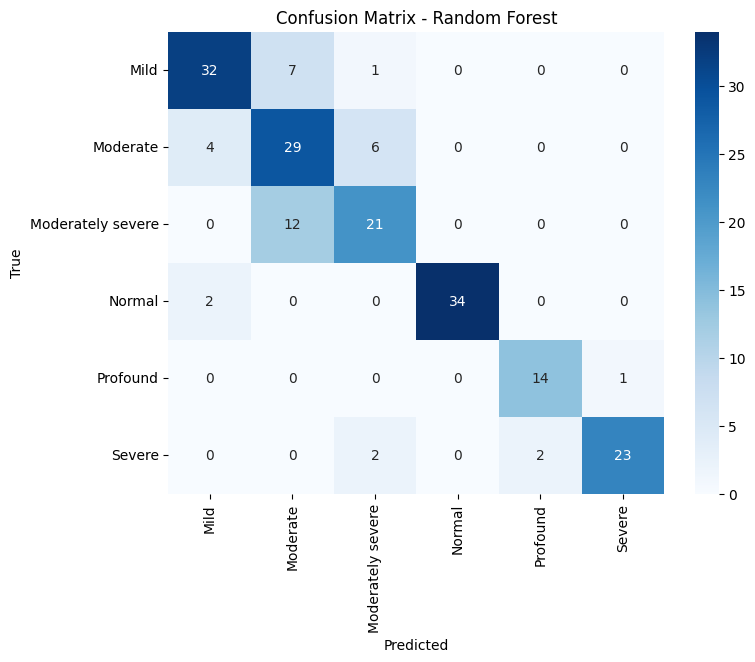


=== SVM (RBF) نتائج ===
Accuracy: 80.0 %
                   precision    recall  f1-score   support

             Mild       0.81      0.75      0.78        40
         Moderate       0.62      0.74      0.67        39
Moderately severe       0.72      0.70      0.71        33
           Normal       0.97      0.92      0.94        36
         Profound       0.83      1.00      0.91        15
           Severe       1.00      0.81      0.90        27

         accuracy                           0.80       190
        macro avg       0.83      0.82      0.82       190
     weighted avg       0.81      0.80      0.80       190



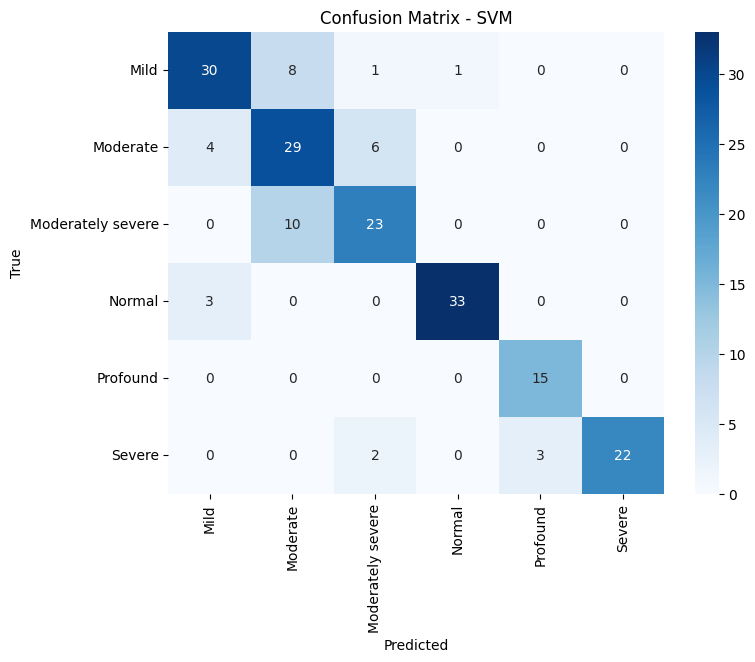


✅ Saved artifacts in: ml_threshold_model
 - ml_threshold_model\rf_model.joblib
 - ml_threshold_model\svm_model.joblib
 - ml_threshold_model\label_encoder.joblib
 - ml_threshold_model\meta.json


In [88]:
# =========================
# 8) RUN
# =========================
if __name__ == "__main__":
    print("=== Training traditional ML on extracted thresholds ===")
    meta = train_and_evaluate()

    # ---- OPTIONAL: test inference on one image from TEST set ----
    # Pick any test image:
    # example_img = os.path.join(TEST_DIR, meta["labels"][0], os.listdir(os.path.join(TEST_DIR, meta["labels"][0]))[0])
    # result = predict_severity_from_image(example_img, model_type="svm", debug=True)
    # print("\nInference example:", json.dumps(result, indent=2))

In [63]:
import joblib

# Load trained ML model bundle
bundle = joblib.load("ml_threshold_model/rf_model.joblib")
model = bundle["model"]
feature_cols = bundle["feature_cols"]

# Load label encoder
le = joblib.load("ml_threshold_model/label_encoder.joblib")


In [64]:
import numpy as np

def predict_severity_from_image(image_path, debug=False):
    """
    Input  : path to an audiogram image
    Output : predicted severity + confidence + thresholds
    """

    # 1) Extract thresholds
    thresholds = extract_thresholds_from_image(image_path, debug=debug)

    # 2) Convert thresholds -> engineered features
    feats = thresholds_to_features(thresholds)
    X = np.array([[feats[c] for c in feature_cols]])

    # 3) Predict using trained ML model
    probs = model.predict_proba(X)[0]
    idx = int(np.argmax(probs))
    pred_label = le.inverse_transform([idx])[0]
    confidence = float(probs[idx])

    # 4) Return results
    return {
        "image_path": image_path,
        "predicted_severity": pred_label,
        "confidence": round(confidence * 100, 2),
        "thresholds_db": [round(t, 1) for t in thresholds],
        "class_probabilities": {
            le.inverse_transform([i])[0]: round(p * 100, 2)
            for i, p in enumerate(probs)
        }
    }


In [92]:
img_path = "C://Users//user//OneDrive//Desktop//speechbanana//test1.png"

result = predict_severity_from_image(img_path, model_type="rf", debug=False)
print(result)


{'image_path': 'C://Users//user//OneDrive//Desktop//speechbanana//test1.png', 'predicted_label': 'Profound', 'confidence': 1.0, 'thresholds_db': [86.72578430175781, 86.67278289794922, 86.67278289794922, 86.67278289794922, 86.67278289794922, 86.67278289794922, 86.72578430175781], 'freqs': [500, 1000, 2000, 3000, 4000, 6000, 8000], 'all_class_probs': [0.0, 0.0, 0.0, 0.0, 1.0, 0.0]}


In [93]:
img_path = "C://Users//user//OneDrive//Desktop//speechbanana//test2.png"

result = predict_severity_from_image(img_path, model_type="rf", debug=False)
print(result)


{'image_path': 'C://Users//user//OneDrive//Desktop//speechbanana//test2.png', 'predicted_label': 'Severe', 'confidence': 0.9825, 'thresholds_db': [74.41165924072266, 72.77657318115234, 74.59870147705078, 76.9414291381836, 79.90409851074219, 56.09194564819336, 56.09194564819336], 'freqs': [500, 1000, 2000, 3000, 4000, 6000, 8000], 'all_class_probs': [0.0, 0.0, 0.0175, 0.0, 0.0, 0.9825]}


In [99]:
img_path = "C://Users//user//OneDrive//Desktop//speechbanana//test3.png"

result = predict_severity_from_image(img_path, model_type="rf", debug=False)
print("Predicted:", result["predicted_label"])
if result["confidence"] is not None:
    print("Confidence:", round(result["confidence"]*100, 2), "%")
print("Thresholds:", [round(x,1) for x in result["thresholds_db"]])

print("Using model:", type(model))


Predicted: Moderately severe
Confidence: 78.99 %
Thresholds: [25.4, 23.1, 21.0, 18.9, 16.1, 45.7, 72.4]
Using model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
img_path = "C://Users//user//OneDrive//Desktop//speechbanana//test4.png"

result = predict_severity_from_image(img_path, model_type="rf", debug=False)
print("Predicted:", result["predicted_label"])
if result["confidence"] is not None:
    print("Confidence:", round(result["confidence"]*100, 2), "%")
print("Thresholds:", [round(x,1) for x in result["thresholds_db"]])
print("Using model:", type(model))


Predicted: Severe
Confidence: 99.5 %
Thresholds: [64.2, 66.3, 70.8, 75.1, 79.9, 66.2, 80.5]
Using model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [101]:
img_path = "C://Users//user//OneDrive//Desktop//speechbanana//test5.png"

result = predict_severity_from_image(img_path, model_type="rf", debug=False)
print("Predicted:", result["predicted_label"])
if result["confidence"] is not None:
    print("Confidence:", round(result["confidence"]*100, 2), "%")
print("Thresholds:", [round(x,1) for x in result["thresholds_db"]])
print("Using model:", type(model))


Predicted: Moderate
Confidence: 66.65 %
Thresholds: [-2.0, 23.2, 31.8, 48.4, 71.5, 79.4, 48.2]
Using model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [103]:
img_path = "C:\\Users\\user\\OneDrive\\Desktop\\speechbanana\\dataset_split.1\\test\\Profound\\audiogram_778132.png"

result = predict_severity_from_image(img_path, model_type="rf", debug=False)
print("Predicted:", result["predicted_label"])
if result["confidence"] is not None:
    print("Confidence:", round(result["confidence"]*100, 2), "%")
print("Thresholds:", [round(x,1) for x in result["thresholds_db"]])
print("Using model:", type(model))


Predicted: Profound
Confidence: 100.0 %
Thresholds: [86.7, 86.7, 86.7, 86.7, 86.7, 86.7, 86.7]
Using model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [32]:
import os

print("TRAIN exists:", os.path.exists(TRAIN_DIR))
print("TEST exists :", os.path.exists(TEST_DIR))

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    print(cls, "->", len(os.listdir(cls_path)))


TRAIN exists: True
TEST exists : True
Mild -> 128
Moderate -> 123
Moderately severe -> 108
Normal -> 128
Profound -> 54
Severe -> 93


[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Moderately severe\audiogram_145526.png -> Too many missing columns in C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Moderately severe\audiogram_145526.png. Detected columns=2 (need at least 3).
[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_16.png -> Too many missing columns in C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_16.png. Detected columns=2 (need at least 3).
[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_166.png -> Too many missing columns in C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_166.png. Detected columns=2 (need at least 3).
[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_183.png -> Too few blue components in C:\Users\user\OneDrive\Desktop\speechban

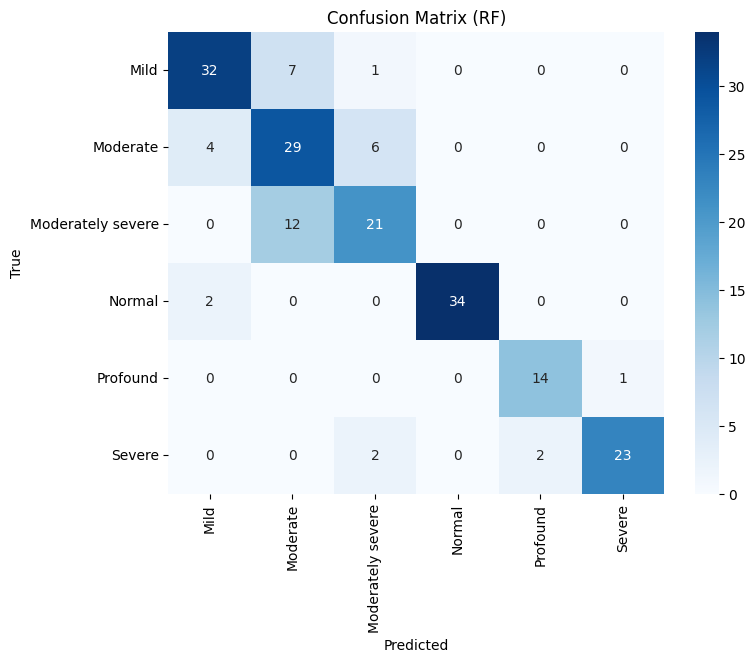


--- Model parameters (get_params) ---
bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 12
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 400
n_jobs: None
oob_score: False
random_state: 42
verbose: 0
warm_start: False

--- Top Feature Importances (RF) ---
   feature  importance
   avg_thr    0.155444
speech_avg    0.121392
  high_avg    0.095579
   min_thr    0.092575
   low_avg    0.090673
   max_thr    0.087149
   thr_500    0.071140
    thr_6k    0.063974
    thr_8k    0.043206
    thr_4k    0.039936
    thr_1k    0.039429
    thr_3k    0.031106
    thr_2k    0.029887
  variance    0.021513
     slope    0.016999


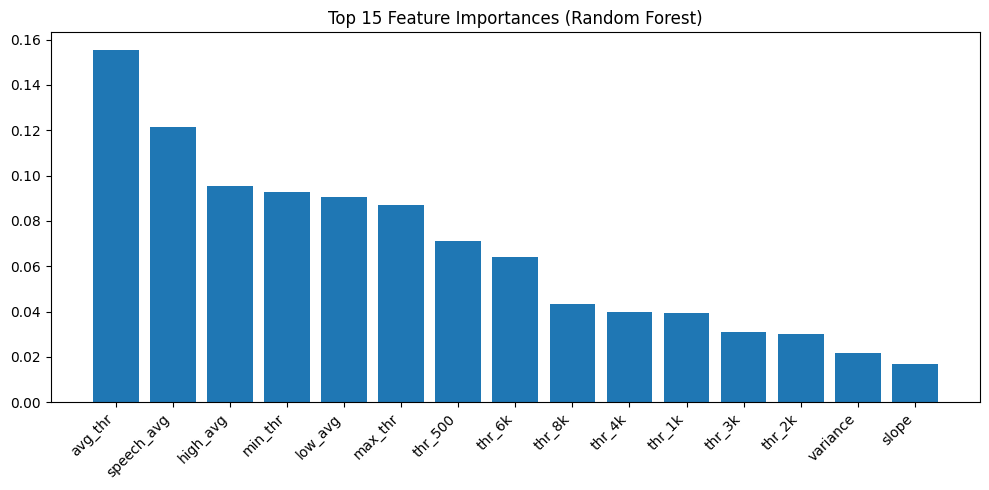

[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Moderately severe\audiogram_145526.png -> Too many missing columns in C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Moderately severe\audiogram_145526.png. Detected columns=2 (need at least 3).
[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_16.png -> Too many missing columns in C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_16.png. Detected columns=2 (need at least 3).
[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_166.png -> Too many missing columns in C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_166.png. Detected columns=2 (need at least 3).
[WARN] Skipping C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Normal\audiogram_183.png -> Too few blue components in C:\Users\user\OneDrive\Desktop\speechban

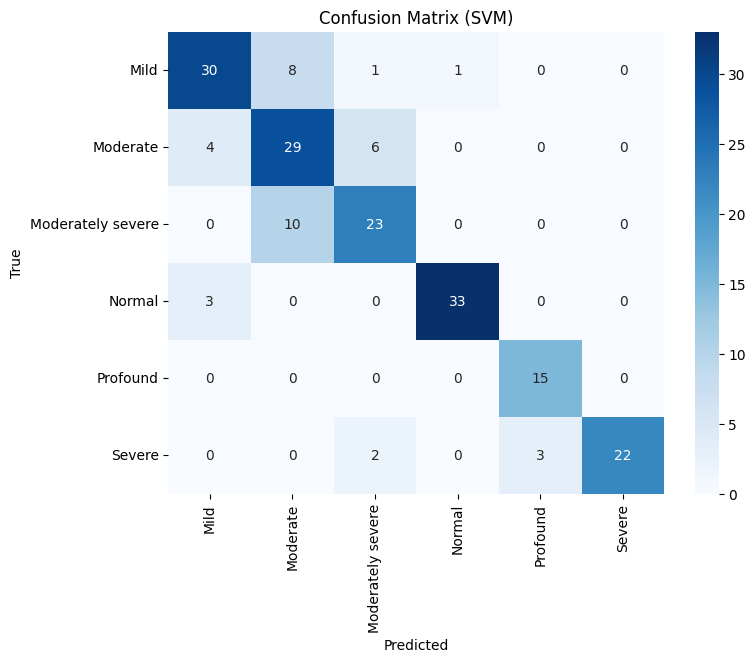


--- Model parameters (get_params) ---
memory: None
scaler: StandardScaler()
scaler__copy: True
scaler__with_mean: True
scaler__with_std: True
steps: [('scaler', StandardScaler()), ('svc', SVC(class_weight='balanced', probability=True, random_state=42))]
svc: SVC(class_weight='balanced', probability=True, random_state=42)
svc__C: 1.0
svc__break_ties: False
svc__cache_size: 200
svc__class_weight: balanced
svc__coef0: 0.0
svc__decision_function_shape: ovr
svc__degree: 3
svc__gamma: scale
svc__kernel: rbf
svc__max_iter: -1
svc__probability: True
svc__random_state: 42
svc__shrinking: True
svc__tol: 0.001
svc__verbose: False
transform_input: None
verbose: False


SUMMARY COMPARISON
------------------------------------------------------------
RF  -> Acc: 80.53% | Macro F1: 0.822 | Weighted F1: 0.809
SVM -> Acc: 80.00% | Macro F1: 0.819 | Weighted F1: 0.803


In [102]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# =========================
# 0) PATHS (edit if needed)
# =========================
BASE_DIR = r"C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1"
TEST_DIR = os.path.join(BASE_DIR, "test")

OUT_DIR = "ml_threshold_model"
MODEL_PATH_RF = os.path.join(OUT_DIR, "rf_model.joblib")
MODEL_PATH_SVM = os.path.join(OUT_DIR, "svm_model.joblib")
LABEL_ENCODER_PATH = os.path.join(OUT_DIR, "label_encoder.joblib")
META_PATH = os.path.join(OUT_DIR, "meta.json")


# =========================
# 1) LOAD ARTIFACTS
# =========================
def load_bundle(model_type="rf"):
    le = joblib.load(LABEL_ENCODER_PATH)
    meta = json.load(open(META_PATH, "r"))

    if model_type.lower() == "rf":
        bundle = joblib.load(MODEL_PATH_RF)
    else:
        bundle = joblib.load(MODEL_PATH_SVM)

    model = bundle["model"]
    feature_cols = bundle["feature_cols"]
    return model, feature_cols, le, meta


# =========================
# 2) PREPARE TEST SET
# =========================
def prepare_test_xy(feature_cols, le):
    df_test = build_feature_dataframe(TEST_DIR)

    if df_test.empty:
        raise RuntimeError("df_test is empty. Threshold extraction skipped too many images.")

    X_test = df_test[feature_cols].astype(np.float32).values
    y_test = le.transform(df_test["label"].values)

    return df_test, X_test, y_test


# =========================
# 3) EVALUATE ANY MODEL
# =========================
def evaluate_model(model_type="rf"):
    model, feature_cols, le, meta = load_bundle(model_type=model_type)
    df_test, X_test, y_test = prepare_test_xy(feature_cols, le)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Precision/Recall/F1 summary
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

    # Labels for reporting
    class_names = list(le.classes_)

    print("\n" + "="*80)
    print(f"MODEL TYPE: {model_type.upper()}   |   Classifier: {type(model)}")
    print("="*80)

    print(f"Test samples used (after skips): {len(df_test)}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Macro   P/R/F1: {prec_m:.3f} / {rec_m:.3f} / {f1_m:.3f}")
    print(f"Weighted P/R/F1: {prec_w:.3f} / {rec_w:.3f} / {f1_w:.3f}")

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Show model parameters
    print("\n--- Model parameters (get_params) ---")
    params = model.get_params()
    for k in sorted(params.keys()):
        print(f"{k}: {params[k]}")

    # If Random Forest: feature importances
    if model_type.lower() == "rf" and hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances})
        imp_df = imp_df.sort_values("importance", ascending=False)

        print("\n--- Top Feature Importances (RF) ---")
        print(imp_df.head(15).to_string(index=False))

        plt.figure(figsize=(10,5))
        plt.bar(imp_df["feature"].head(15), imp_df["importance"].head(15))
        plt.xticks(rotation=45, ha="right")
        plt.title("Top 15 Feature Importances (Random Forest)")
        plt.tight_layout()
        plt.show()

    return {
        "model_type": model_type,
        "accuracy": acc,
        "macro_f1": f1_m,
        "weighted_f1": f1_w,
        "samples_used": len(df_test),
        "skipped_info": meta.get("skipped_info", None),
    }


# =========================
# 4) RUN BOTH MODELS
# =========================
rf_results = evaluate_model("rf")
svm_results = evaluate_model("svm")

print("\n\nSUMMARY COMPARISON")
print("-"*60)
print(f"RF  -> Acc: {rf_results['accuracy']*100:.2f}% | Macro F1: {rf_results['macro_f1']:.3f} | Weighted F1: {rf_results['weighted_f1']:.3f}")
print(f"SVM -> Acc: {svm_results['accuracy']*100:.2f}% | Macro F1: {svm_results['macro_f1']:.3f} | Weighted F1: {svm_results['weighted_f1']:.3f}")
